# FPL Point Prediction

## 1. Preprocessing

### 1.1. Libraries

In [47]:
import os
from dotenv import load_dotenv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine, text

load_dotenv();

### 1.2. Import data

In [48]:
df = pd.read_csv('./input.csv')
df.head()

,player_id,position,game_id,datetime,year,month,day,hour,team_id,opponent_team_id,...,win_rate_prior,win_rate_last_5_prior,win_rate_vs_opponent_prior,total_games_vs_opponent_prior,avg_goals_scored_prior,avg_expected_goals_prior,avg_goals_scored_last_5_prior,avg_expected_goals_last_5_prior,avg_goals_scored_vs_opponent_prior,avg_expected_goals_vs_opponent_prior
0,02d7c5e2-e436-461b-95e5-853765be5a86,2,5e51b211-42bc-4c0c-a99d-860c8df03c80,2017-10-14 14:00:00.000000,2017,10,14,14,00f2aba7-b2c2-41d9-bfb6-d699954d00c4,1f0aeb7b-4ade-4beb-9842-a9fe08d61bdb,...,0.325000,0.4,0.000000,2,NaN,NaN,NaN,NaN,NaN,NaN
1,02d7c5e2-e436-461b-95e5-853765be5a86,2,eb470b5d-d48a-4d80-85a7-52281f46a8f8,2017-12-09 15:00:00.000000,2017,12,9,15,00f2aba7-b2c2-41d9-bfb6-d699954d00c4,c36859ee-41f5-4436-b074-52bf466bd03c,...,0.312500,0.2,0.000000,2,NaN,NaN,NaN,NaN,NaN,NaN
2,02d7c5e2-e436-461b-95e5-853765be5a86,2,e95e98ad-bf80-4258-b407-fa350dedbf4f,2017-12-12 19:45:00.000000,2017,12,12,19,00f2aba7-b2c2-41d9-bfb6-d699954d00c4,400ce689-140a-4090-a2b3-9f1efcf49197,...,0.306122,0.2,0.500000,2,NaN,NaN,NaN,NaN,NaN,NaN
3,02d7c5e2-e436-461b-95e5-853765be5a86,2,0b614495-8728-4f1b-b8eb-31afdbb5db2c,2018-04-22 12:30:00.000000,2018,4,22,12,00f2aba7-b2c2-41d9-bfb6-d699954d00c4,400ce689-140a-4090-a2b3-9f1efcf49197,...,0.272727,0.0,0.333333,3,NaN,NaN,NaN,NaN,NaN,NaN
4,faa6df39-9f37-4a86-bb1a-58232e80156e,2,8527db7a-f7f7-4f74-ab67-6fb4a5add1f9,2018-11-24 15:00:00.000000,2018,11,24,15,00f7a08d-8096-49b3-839a-b438b1158e01,298e371c-41d1-497f-b9af-fd2deed6562c,...,0.083333,0.0,NaN,0,0.0,0.005,0.0,0.0,NaN,NaN


### 1.3. Preliminary analysis

#### 1.3.1. Numeric data

In [49]:
non_numeric_columns = df.select_dtypes(exclude=[np.number]).columns
bool_columns = df.select_dtypes(include=[bool]).columns
string_cols = df.select_dtypes(include=[object]).columns
columns_to_exclude = list(set(non_numeric_columns) - set(bool_columns))

print("Boolean columns: ", bool_columns)
print("String columns: ", string_cols)
print("Columns to exclude: ", columns_to_exclude)

Boolean columns:  Index(['is_home'], dtype='str')
String columns:  Index(['player_id', 'game_id', 'datetime', 'team_id', 'opponent_team_id'], dtype='str')
Columns to exclude:  ['game_id', 'datetime', 'team_id', 'player_id', 'opponent_team_id']


/tmp/ipykernel_8261/2683136312.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  string_cols = df.select_dtypes(include=[object]).columns


In [50]:
# Numeric data
numeric_df = df[df.columns.difference(columns_to_exclude)]
numeric_df[bool_columns] = numeric_df[bool_columns].astype(int)

# Numeric non-null data
numeric_non_null_df = numeric_df.dropna()

#### 1.3.2. Distribution of values per column

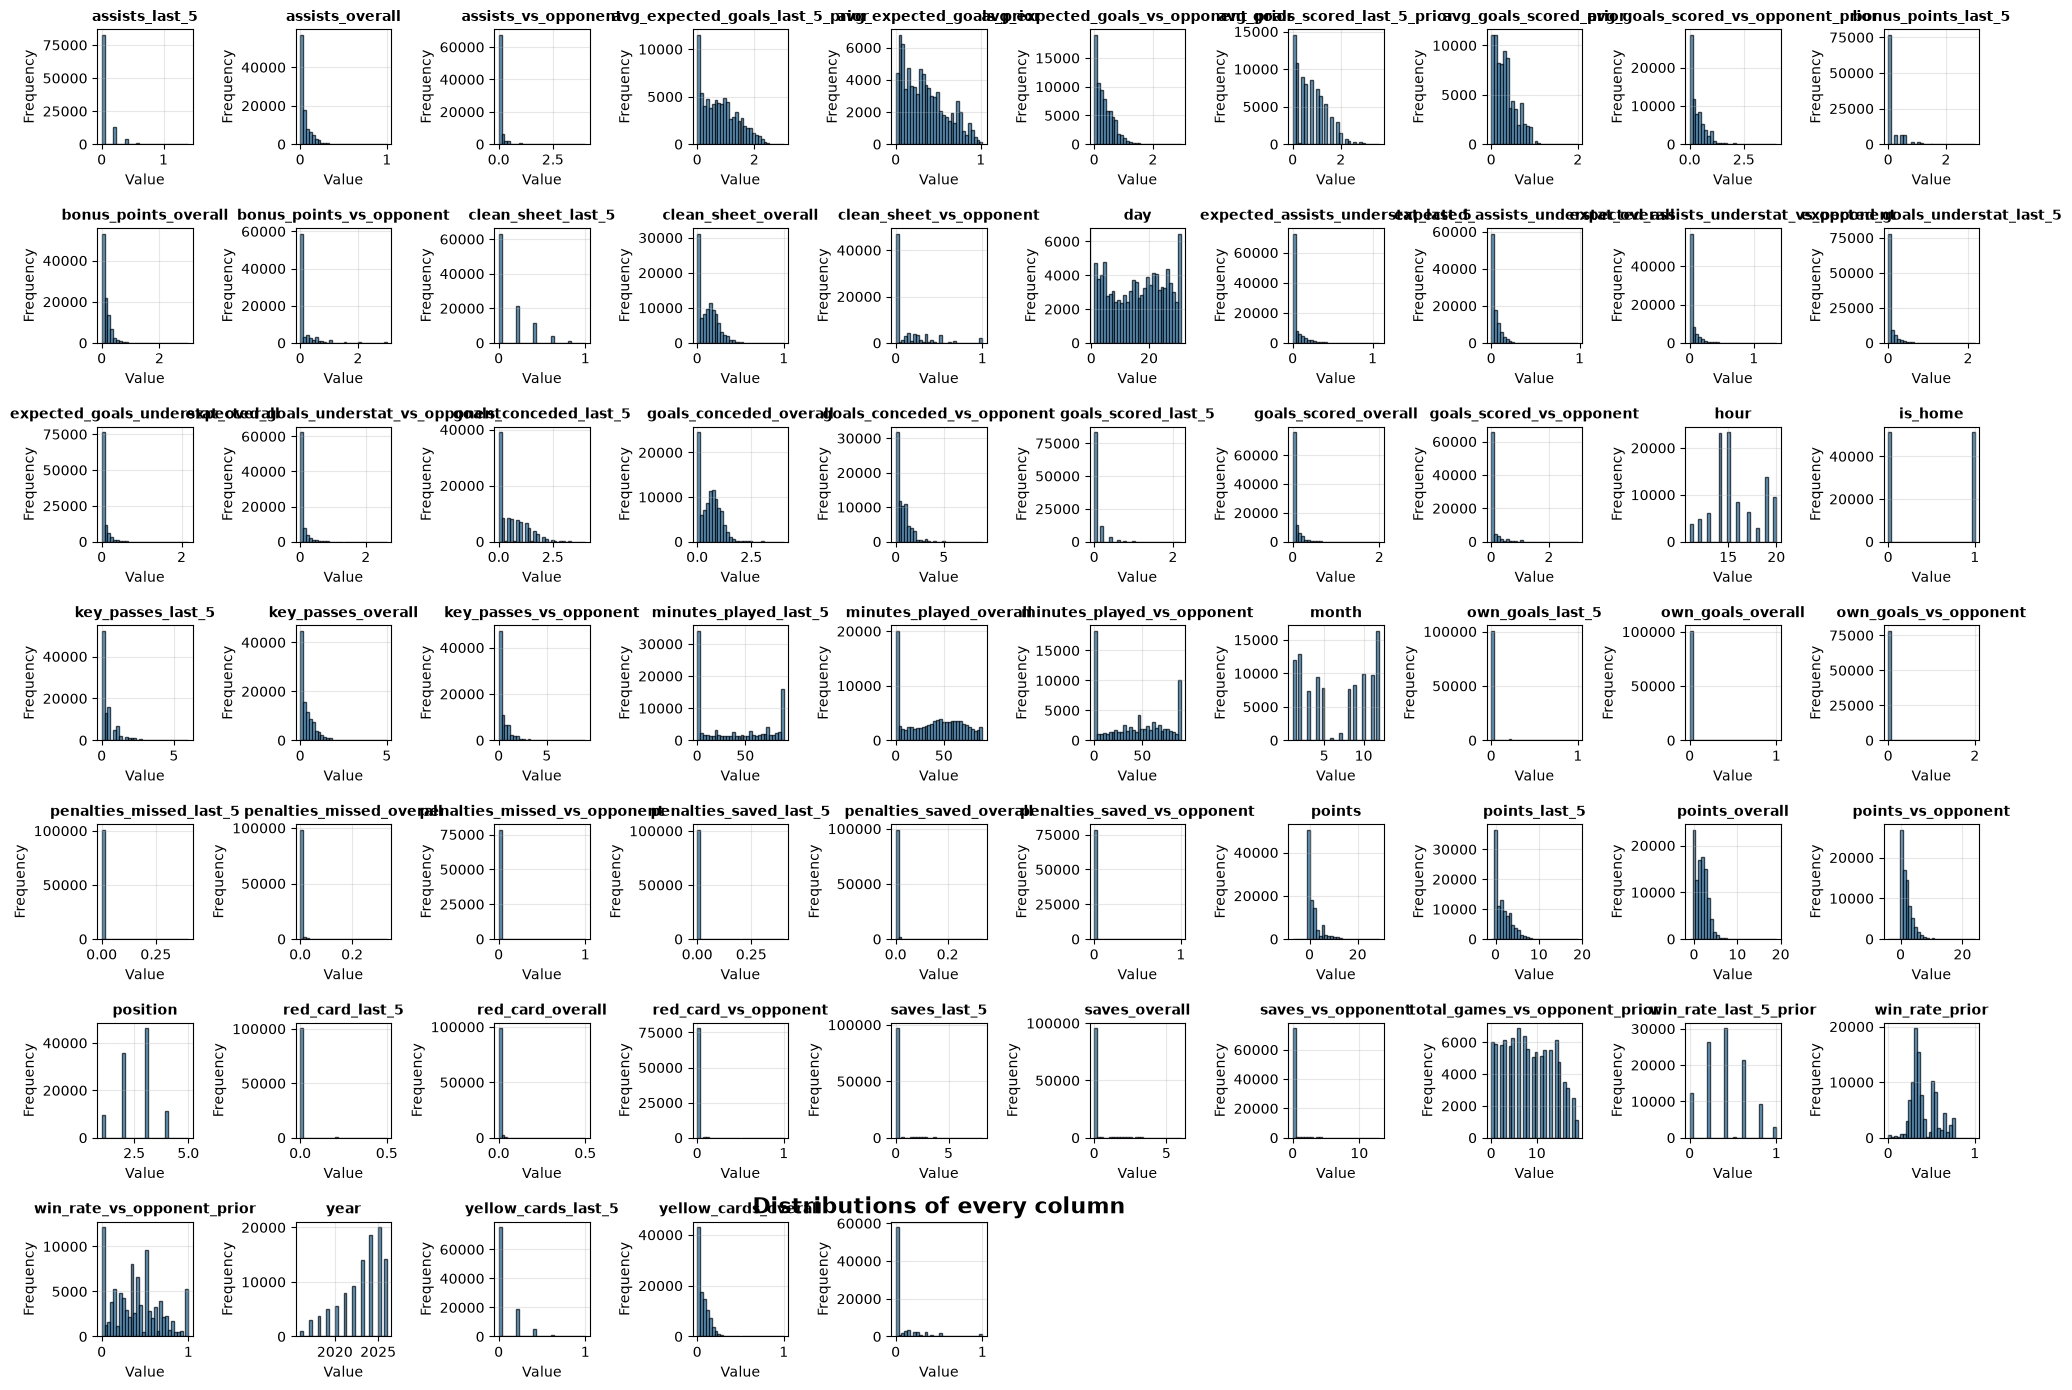

,Missing Count,Percentage (%)
avg_goals_scored_vs_opponent_prior,28290,27.570144
avg_expected_goals_vs_opponent_prior,28290,27.570144
minutes_played_vs_opponent,23678,23.075499
goals_scored_vs_opponent,23678,23.075499
yellow_cards_vs_opponent,23678,23.075499
assists_vs_opponent,23678,23.075499
expected_assists_understat_vs_opponent,23678,23.075499
goals_conceded_vs_opponent,23678,23.075499
points_vs_opponent,23678,23.075499
own_goals_vs_opponent,23678,23.075499


In [51]:
# Create figure with subplots
n_cols = len(numeric_df.columns)
cols_per_row = 10
n_rows = (n_cols + cols_per_row - 1) // cols_per_row

fig, axes = plt.subplots(n_rows, cols_per_row, figsize=(20, n_rows * 2))
axes = axes.flatten()

# Plot distribution for each column
for idx, col in enumerate(numeric_df.columns):
    axes[idx].hist(numeric_df[col].dropna(), bins=30, edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'{col}', fontsize=10, fontweight='bold')
    axes[idx].set_xlabel('Value')
    axes[idx].set_ylabel('Frequency')
    axes[idx].grid(True, alpha=0.3)

# Remove extra subplots
for idx in range(len(numeric_df.columns), len(axes)):
    fig.delaxes(axes[idx])

plt.title('Distributions of every column', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Exact null distribution
missing_values = df.isnull().sum()
percentage = (missing_values / len(df)) * 100

missing_values_df = pd.DataFrame({'Missing Count': missing_values, 'Percentage (%)': percentage})
missing_values_df = missing_values_df[missing_values_df['Missing Count'] > 0]
missing_values_df = missing_values_df.sort_values(by='Percentage (%)', ascending=False)

missing_values_df

#### 1.3.3. Correlation matrix

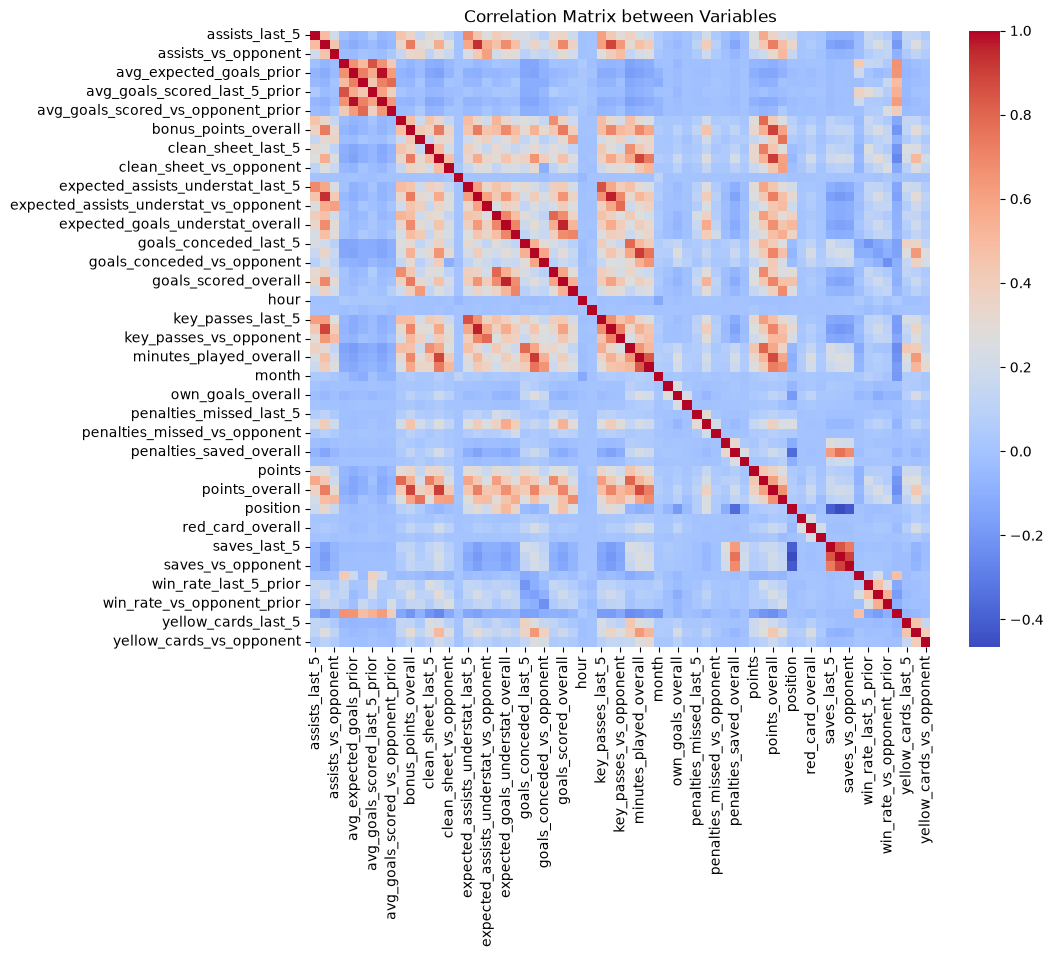

In [52]:
corr_matrix = numeric_non_null_df.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm')
plt.title('Correlation Matrix between Variables')
plt.show()

### 1.4. Data sets

In [53]:
df = df.sort_values(by='datetime', ascending=True)
df[bool_columns] = df[bool_columns].astype(int)

#### 1.4.1. Input and Output split

In [54]:
# Identifiers
data_ids = df[string_cols]

# Output
target_value = 'points'
y = df[target_value]

# Input
columns_to_exclude_input = columns_to_exclude + [target_value]
X = df.drop(columns=columns_to_exclude_input)

#### 1.4.2. Train/Validation/Test split

In [55]:
len_data = len(X)
train_percent = 0.65
val_percent = 0.80

train_end = int(train_percent * len_data)
val_end = int(val_percent * len_data)

# Input splits
X_train_split = X.iloc[:train_end]
X_val_split   = X.iloc[train_end:val_end]
X_test_split  = X.iloc[val_end:]

# Output splits
y_train = y.iloc[:train_end]
y_val   = y.iloc[train_end:val_end]
y_test  = y.iloc[val_end:]

In [56]:
# Attach string identifiers (like opponent_team_id) to features for mapping
X_train_ids = data_ids.iloc[:train_end]
X_train_identified = pd.concat([X_train_ids, X_train_split], axis=1)

X_val_ids = data_ids.iloc[train_end:val_end]
X_val_identified = pd.concat([X_val_ids, X_val_split], axis=1)

X_test_ids = data_ids.iloc[val_end:]
X_test_identified = pd.concat([X_test_ids, X_test_split], axis=1)

#### 1.4.3. Missing values handling

In [57]:
def build_imputation_lookups(X_train: pd.DataFrame, missing_values_columns: list) -> dict:
    lookups = {}

    last_5_cols = [c for c in missing_values_columns if c.endswith('last_5')]
    overall_cols = [c for c in missing_values_columns if c.endswith('overall')]
    vs_opp_cols = [c for c in missing_values_columns if c.endswith('vs_opponent')]
    prior_cols = [c for c in missing_values_columns if c.endswith('prior')]

    # Global means across all rows in X_train
    global_cols = last_5_cols + overall_cols
    if global_cols:
        lookups['global'] = X_train[global_cols].mean()

    # Grouped means by opponent_team_id in X_train
    opponent_cols = vs_opp_cols + prior_cols
    if opponent_cols:
        lookups['opponent'] = X_train.groupby('opponent_team_id')[opponent_cols].mean()
        lookups['extra_opponent'] = X_train[opponent_cols].mean()

    return lookups

In [58]:
def fill_rolling_missing_values(df: pd.DataFrame, missing_values_columns: list, lookups: dict) -> pd.DataFrame:
    df_imputed = df.copy()

    last_5_cols = [c for c in missing_values_columns if c.endswith('last_5')]
    overall_cols = [c for c in missing_values_columns if c.endswith('overall')]
    vs_opp_cols = [c for c in missing_values_columns if c.endswith('vs_opponent')]
    prior_cols = [c for c in missing_values_columns if c.endswith('prior')]

    global_cols = last_5_cols + overall_cols
    opp_cols = vs_opp_cols + prior_cols

    # Global columns fillna
    if global_cols and 'global' in lookups:
        df_imputed[global_cols] = df_imputed[global_cols].fillna(lookups['global'])

    # Opponent specific columns fillna
    if opp_cols and 'opponent' in lookups:
        # 1. Primary Imputation: Match opponent_team_id to X_train opponent averages
        opp_means = df_imputed[['opponent_team_id']].merge(
            lookups['opponent'],
            left_on='opponent_team_id',
            right_index=True,
            how='left'
        )
        opp_means.index = df_imputed.index
        df_imputed[opp_cols] = df_imputed[opp_cols].fillna(opp_means[opp_cols])

        df_imputed[opp_cols] = df_imputed[opp_cols].fillna(lookups['extra_opponent'])

    return df_imputed

In [59]:
missing_values_columns = X_train_split.columns[X_train_split.isnull().any()].tolist()
rolling_imputations = build_imputation_lookups(X_train_identified, missing_values_columns)

# Input
X_train_filled = fill_rolling_missing_values(X_train_identified, missing_values_columns, rolling_imputations)
X_val_filled   = fill_rolling_missing_values(X_val_identified, missing_values_columns, rolling_imputations)
X_test_filled  = fill_rolling_missing_values(X_test_identified, missing_values_columns, rolling_imputations)

# Output
X_train = X_train_filled.drop(columns=string_cols)
X_val = X_val_filled.drop(columns=string_cols)
X_test = X_test_filled.drop(columns=string_cols)

In [60]:
print(X_train.columns)
print(X_val.columns)
print(X_test.columns)

Index(['position', 'year', 'month', 'day', 'hour', 'is_home', 'points_last_5',
       'points_overall', 'points_vs_opponent', 'minutes_played_last_5',
       'minutes_played_overall', 'minutes_played_vs_opponent',
       'goals_scored_last_5', 'goals_scored_overall',
       'goals_scored_vs_opponent', 'expected_goals_understat_last_5',
       'expected_goals_understat_overall',
       'expected_goals_understat_vs_opponent', 'goals_conceded_last_5',
       'goals_conceded_overall', 'goals_conceded_vs_opponent',
       'assists_last_5', 'assists_overall', 'assists_vs_opponent',
       'expected_assists_understat_last_5',
       'expected_assists_understat_overall',
       'expected_assists_understat_vs_opponent', 'yellow_cards_last_5',
       'yellow_cards_overall', 'yellow_cards_vs_opponent', 'red_card_last_5',
       'red_card_overall', 'red_card_vs_opponent', 'clean_sheet_last_5',
       'clean_sheet_overall', 'clean_sheet_vs_opponent', 'key_passes_last_5',
       'key_passes_overall'

#### 1.4.4. Data normalization

In [61]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)
X_val_scaled = pd.DataFrame(
    scaler.transform(X_val),
    columns=X_val.columns,
    index=X_val.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

#### 1.4.5. PCA analysis

In [62]:
%unload_ext cuml.accel

The cuml.accel extension is not loaded.


In [63]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.80)

# FIT ONLY ON TRAIN
X_train_pca = pca.fit_transform(X_train_scaled)

# TRANSFORM OTHERS
X_val_pca   = pca.transform(X_val_scaled)
X_test_pca  = pca.transform(X_test_scaled)

print("Number of PCA components:", pca.n_components_)

Number of PCA components: 24


## 2. Prediction

In [64]:
X_train_np = np.asarray(X_train_scaled)
X_val_np = np.asarray(X_val_scaled)
X_test_np = np.asarray(X_test_scaled)

y_train_np = np.asarray(y_train).ravel().astype(float)
y_val_np = np.asarray(y_val).ravel().astype(float)
y_test_np = np.asarray(y_test).ravel().astype(float)

### 2.1. Regressor

In [ ]:
from sklearn.ensemble import HistGradientBoostingRegressor

point_model = HistGradientBoostingRegressor(
    loss='squared_error',
    learning_rate=0.08,
    max_iter=250,
    max_leaf_nodes=31,
    l2_regularization=1.0,
    random_state=42,
)
point_model.fit(X_train_np, y_train_np)

val_prediction = point_model.predict(X_val_np)
test_prediction = point_model.predict(X_test_np)

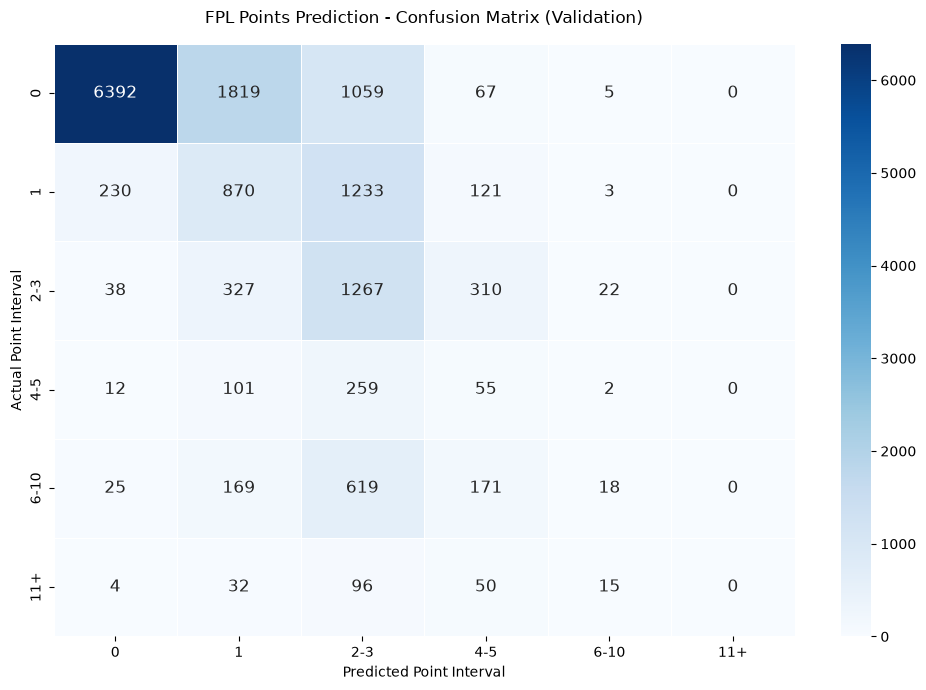

In [ ]:
from sklearn.metrics import confusion_matrix

# Intervals and labels for categorization
bins = [-np.inf, 0.5, 1.5, 3.5, 5.5, 10.5, np.inf]
labels = ['0', '1', '2-3', '4-5', '6-10', '11+']

# Categorization of actuals and predictions
y_val_binned = pd.cut(y_val_np.flatten(), bins=bins, labels=labels)
val_pred_binned = pd.cut(val_prediction.flatten(), bins=bins, labels=labels)

# Confusion matrix
cm = confusion_matrix(y_val_binned, val_pred_binned, labels=labels)

# Plot
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=labels, yticklabels=labels,
            linewidths=0.5, annot_kws={"size": 12})

plt.title('FPL Points Prediction - Confusion Matrix (Validation)', pad=15)
plt.xlabel('Predicted Point Interval')
plt.ylabel('Actual Point Interval')
plt.tight_layout()
plt.show()

In [70]:
from sklearn.metrics import classification_report, cohen_kappa_score, mean_absolute_error, mean_squared_error

# Classification Metrics (Precision, Recall, F1)
print("--- Classification Report (Binned) ---")
print(classification_report(y_val_binned, val_pred_binned, labels=labels, zero_division=0))

# Ordinal Metric: Quadratic Weighted Kappa
label_to_int = {label: i for i, label in enumerate(labels)}
y_val_ints = [label_to_int[val] for val in y_val_binned]
val_pred_ints = [label_to_int[val] for val in val_pred_binned]

kappa = cohen_kappa_score(y_val_ints, val_pred_ints, weights='quadratic')
print(f"\n--- Ordinal Metric ---")
print(f"Quadratic Weighted Kappa: {kappa:.4f}")

# Regression Metrics (Raw Continuous Predictions)
mae = mean_absolute_error(y_val_np, val_prediction)
rmse = mean_squared_error(y_val_np, val_prediction) 

print(f"\n--- Raw Regression Metrics ---")
print(f"Mean Absolute Error (MAE): {mae:.2f} points")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} points")

--- Classification Report (Binned) ---
              precision    recall  f1-score   support

           0       0.95      0.68      0.80      9342
           1       0.26      0.35      0.30      2457
         2-3       0.28      0.65      0.39      1964
         4-5       0.07      0.13      0.09       429
        6-10       0.28      0.02      0.03      1002
         11+       0.00      0.00      0.00       197

    accuracy                           0.56     15391
   macro avg       0.31      0.30      0.27     15391
weighted avg       0.68      0.56      0.59     15391


--- Ordinal Metric ---
Quadratic Weighted Kappa: 0.5840

--- Raw Regression Metrics ---
Mean Absolute Error (MAE): 1.14 points
Root Mean Squared Error (RMSE): 4.43 points
